In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

# Bivariant Analysis

In [4]:
house_prices = pd.read_csv('../../datasets/house_prices_cleaned.zip')
house_copy = house_prices.copy()
house_copy.drop(columns= 'Unnamed: 0', axis= 'columns', inplace= True)

C:\Users\HP\AppData\Local\Temp\ipykernel_26212\3938254258.py:1: DtypeWarning: Columns (0: locality) have mixed types. Specify dtype option on import or set low_memory=False.
  house_prices = pd.read_csv('../../datasets/house_prices_cleaned.zip')


In [5]:
house_copy.info()

<class 'pandas.DataFrame'>
RangeIndex: 68192 entries, 0 to 68191
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   title               68192 non-null  str    
 1   description         65974 non-null  str    
 2   amount              67841 non-null  float64
 3   price               63575 non-null  float64
 4   location            68192 non-null  str    
 5   carpet_area         38075 non-null  float64
 6   floor               65577 non-null  str    
 7   transaction         68114 non-null  str    
 8   furnishing          68192 non-null  str    
 9   facing              41392 non-null  str    
 10  overlooking         38657 non-null  str    
 11  society             29372 non-null  str    
 12  bathroom            67721 non-null  float64
 13  balcony             49133 non-null  float64
 14  car_parking         28863 non-null  float64
 15  ownership           43264 non-null  str    
 16  super_area     

<Axes: >

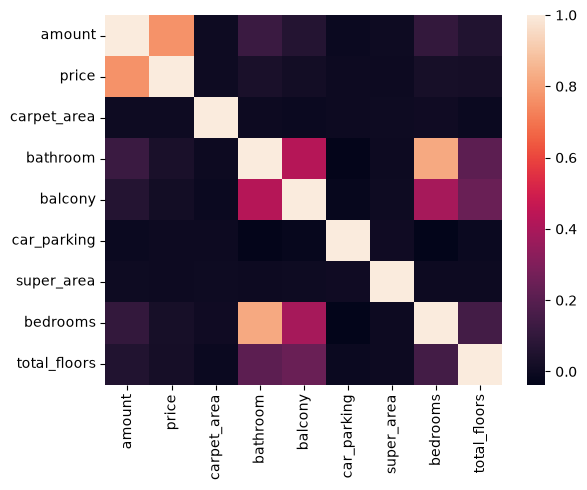

In [8]:
hm = house_copy.corr(numeric_only= True)
sns.heatmap(hm)

In [9]:
def scatter2d(x, y, color= 'blue', linewidth= 0, xscale= False, yscale= False):
    sns.scatterplot(data= house_copy, x= x, y= y, edgecolor= 'black', color= color, linewidth= linewidth)
    if xscale: plt.xscale('log')
    if yscale: plt.yscale('log')

In [10]:
def kde2d(x, y, color= 'blue'):
    col1= np.log(house_copy[x])
    col2= np.log(house_copy[y])
    df = pd.DataFrame({x : col1, y : col2})
    sns.kdeplot(data= df, x= x, y= y, color= color, fill= True)

In [11]:
def box2d(data, x, y, colors):
    plot = sns.boxplot(data= data, x= x, y= y, palette= colors)
    plt.yscale('log')
    plt.xticks(rotation= 90)
    
    for patch in plot.axes.patches:
        patch.set_edgecolor('black')

In [12]:
def voilin(data, x, y, colors):
    plot = sns.violinplot(data= data, x= x, y= y, hue= x, legend= False, palette= colors, inner= None) 
    plt.yscale('log')

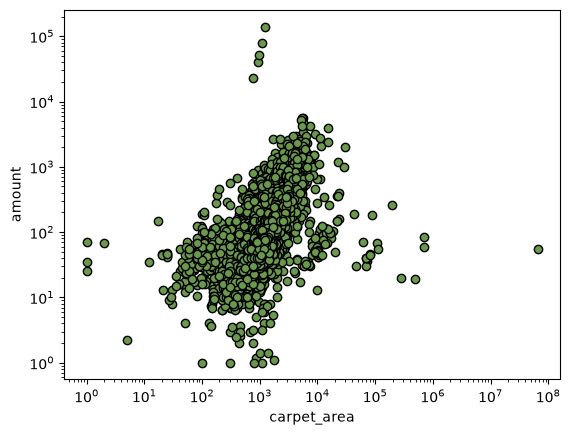

In [13]:
scatter2d('carpet_area', 'amount', '#6a994e', 1, xscale= True, yscale= True)

C:\Users\HP\AppData\Local\Temp\ipykernel_26212\896741144.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.boxplot(data= data, x= x, y= y, palette= colors)


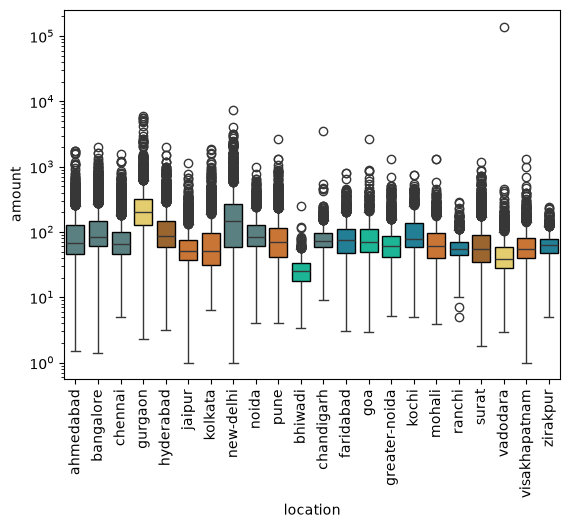

In [14]:
location_top22 = house_copy['location'].value_counts().reset_index().head(22)
df = house_copy[house_copy['location'].isin(location_top22['location'])]
colors= random.choices(['#f6d95b', "#e2711d", '#0e8baa', '#03cea4', '#548687', '#ad651d'], k= 22)
box2d(data= df, x= 'location', y= 'amount', colors= colors)

In [15]:
house_copy.info()

<class 'pandas.DataFrame'>
RangeIndex: 68192 entries, 0 to 68191
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   title               68192 non-null  str    
 1   description         65974 non-null  str    
 2   amount              67841 non-null  float64
 3   price               63575 non-null  float64
 4   location            68192 non-null  str    
 5   carpet_area         38075 non-null  float64
 6   floor               65577 non-null  str    
 7   transaction         68114 non-null  str    
 8   furnishing          68192 non-null  str    
 9   facing              41392 non-null  str    
 10  overlooking         38657 non-null  str    
 11  society             29372 non-null  str    
 12  bathroom            67721 non-null  float64
 13  balcony             49133 non-null  float64
 14  car_parking         28863 non-null  float64
 15  ownership           43264 non-null  str    
 16  super_area     

C:\Users\HP\AppData\Local\Temp\ipykernel_26212\896741144.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.boxplot(data= data, x= x, y= y, palette= colors)


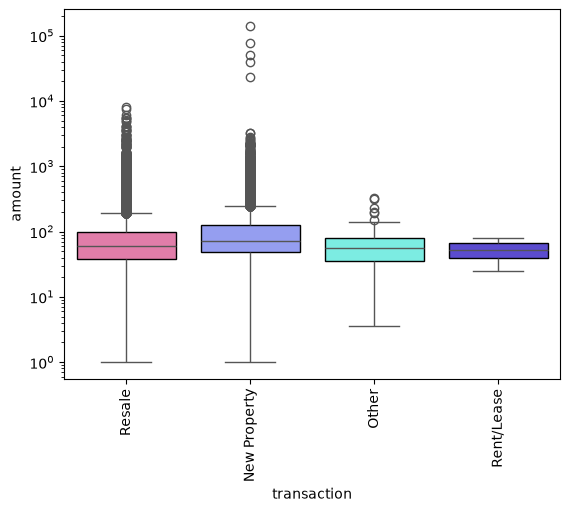

In [16]:
box2d(data= house_copy, x= 'transaction', y= 'amount', colors= ['#f26ca7', '#8692ff', '#69fff1', '#4a36e5'])

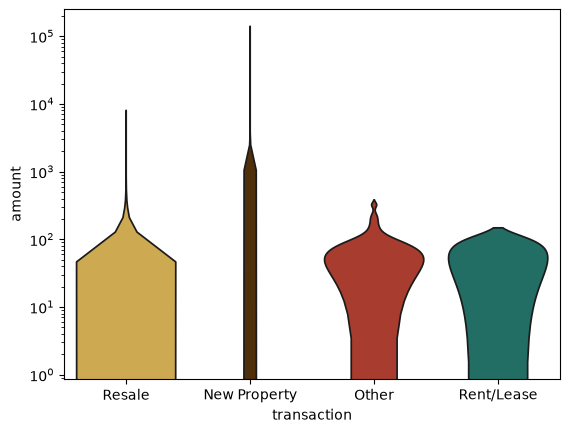

In [17]:
voilin(data= house_copy, x= 'transaction', y= 'amount', colors= ['#e1b23d', '#5b3000', '#bc2c1a', '#157a6e'])


In [18]:
house_copy['transaction'].value_counts()

transaction
Resale          50614
New Property    17438
Other              60
Rent/Lease          2
Name: count, dtype: int64

In [19]:
house_copy['society'] = pd.Series(house_copy['society'].str.title())

C:\Users\HP\AppData\Local\Temp\ipykernel_26212\896741144.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.boxplot(data= data, x= x, y= y, palette= colors)


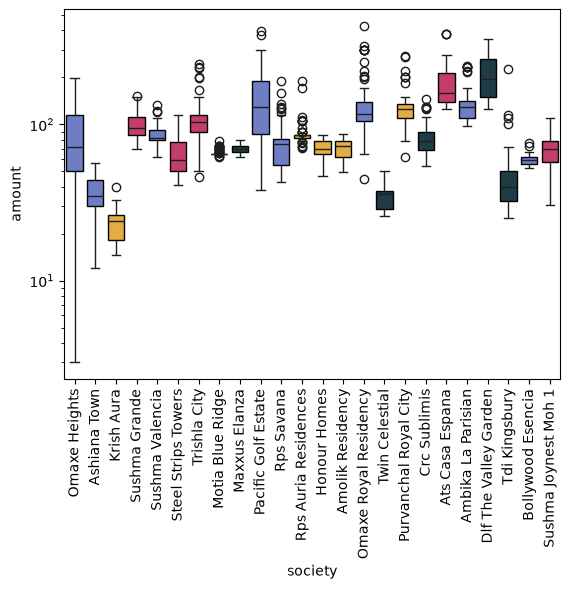

In [20]:
society_count = house_copy['society'].value_counts().head(24)
df = house_copy[house_copy['society'].isin(society_count.index)]
colors= random.choices(['#173f4d', '#db2763', '#6073d2', '#ffb627'], k= 24)
box2d(data= df, x= 'society', y= 'amount', colors= colors)

In [21]:
house_copy.info()

<class 'pandas.DataFrame'>
RangeIndex: 68192 entries, 0 to 68191
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   title               68192 non-null  str    
 1   description         65974 non-null  str    
 2   amount              67841 non-null  float64
 3   price               63575 non-null  float64
 4   location            68192 non-null  str    
 5   carpet_area         38075 non-null  float64
 6   floor               65577 non-null  str    
 7   transaction         68114 non-null  str    
 8   furnishing          68192 non-null  str    
 9   facing              41392 non-null  str    
 10  overlooking         38657 non-null  str    
 11  society             29372 non-null  str    
 12  bathroom            67721 non-null  float64
 13  balcony             49133 non-null  float64
 14  car_parking         28863 non-null  float64
 15  ownership           43264 non-null  str    
 16  super_area     

C:\Users\HP\AppData\Local\Temp\ipykernel_26212\896741144.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.boxplot(data= data, x= x, y= y, palette= colors)


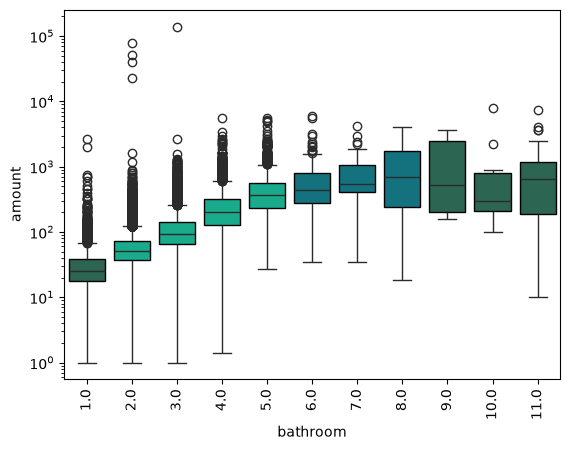

In [22]:
colors= random.choices(['#226f54', '#02c39a', '#028090'], k= 11)
box2d(data= house_copy, x= 'bathroom', y= 'amount', colors= colors)

C:\Users\HP\AppData\Local\Temp\ipykernel_26212\896741144.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.boxplot(data= data, x= x, y= y, palette= colors)


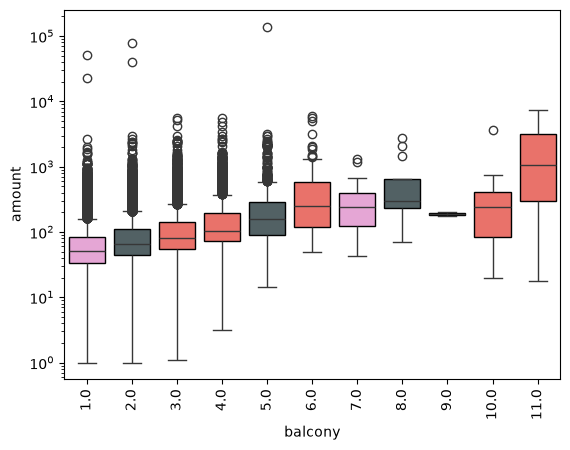

In [24]:
colors= random.choices(['#fe5f55', '#4f6367', '#ef9cda'], k= 11)
box2d(data= house_copy, x= 'balcony', y= 'amount', colors= colors)

In [28]:
(house_copy['balcony'] == 9).sum()

np.int64(2)

C:\Users\HP\AppData\Local\Temp\ipykernel_26212\896741144.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.boxplot(data= data, x= x, y= y, palette= colors)


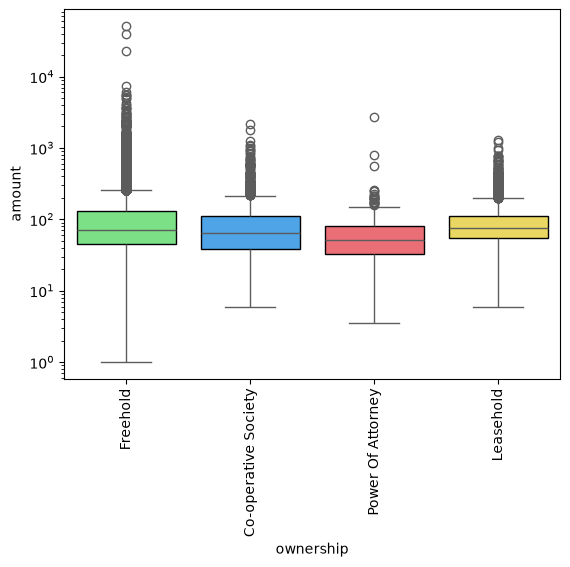

In [31]:
colors= ['#6bf178', '#35a7ff', '#ff5964', '#ffe74c']
box2d(data= house_copy, x= 'ownership', y= 'amount', colors= colors)

C:\Users\HP\AppData\Local\Temp\ipykernel_26212\896741144.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.boxplot(data= data, x= x, y= y, palette= colors)


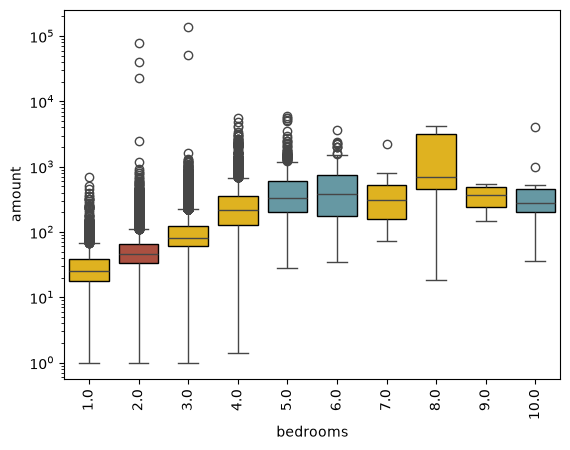

In [34]:
colors= random.choices(['#ffc300', '#bb4430', '#5c9ead'], k= 10)
box2d(data= house_copy, x= 'bedrooms', y= 'amount', colors= colors)

In [40]:
house_copy.info()

<class 'pandas.DataFrame'>
RangeIndex: 68192 entries, 0 to 68191
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   title               68192 non-null  str    
 1   description         65974 non-null  str    
 2   amount              67841 non-null  float64
 3   price               63575 non-null  float64
 4   location            68192 non-null  str    
 5   carpet_area         38075 non-null  float64
 6   floor               65577 non-null  str    
 7   transaction         68114 non-null  str    
 8   furnishing          68192 non-null  str    
 9   facing              41392 non-null  str    
 10  overlooking         38657 non-null  str    
 11  society             29372 non-null  str    
 12  bathroom            67721 non-null  float64
 13  balcony             49133 non-null  float64
 14  car_parking         28863 non-null  float64
 15  ownership           43264 non-null  str    
 16  super_area     